In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.preprocessing import StandardScaler
from PyLTSpice import RawRead
import matplotlib.pyplot as plt
import random

In [ ]:
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(33882356)

In [ ]:
class RCDataset(Dataset):
    def __init__(self,data_file):
        data = np.load(data_file) # load numpy file

        # store mag phase and RC data to separate variables
        mag = data[:, 5:]
        mag = 20*np.log10(mag) # convert to dB
        
        y = np.log10(data[:, :5])

        self.mag_scaler = StandardScaler().fit(mag)
        #self.phase_scaler = StandardScaler().fit(phase)
        self.y_scaler = StandardScaler().fit(y)

        X = self.mag_scaler.transform(mag)
        #phase = self.phase_scaler.transform(phase)
        y = self.y_scaler.transform(y)

        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [ ]:
class RCNet(nn.Module):
    def __init__(self,mag_scaler, y_scaler, input_dim=1, output_dim=5):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv1d(input_dim, 32, kernel_size=5, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2), # Reduce length by 2 (900 -> 450)
            nn.Conv1d(32, 64, kernel_size=5, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2), # Reduce length again (450 -> 225)
            nn.Conv1d(64, 64, kernel_size=5, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(64), # Final feature count (225 -> 32)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 64, 256),  # Input size: 64 channels * 64 sequence length = 2048
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim) # Final output is 5 log-scaled components
        )

        self.register_buffer('mag_mu', torch.tensor(mag_scaler.mean_, dtype=torch.float32))
        self.register_buffer('mag_sigma', torch.tensor(mag_scaler.scale_, dtype=torch.float32))
        self.register_buffer('comp_mu', torch.tensor(y_scaler.mean_, dtype=torch.float32))
        self.register_buffer('comp_sigma', torch.tensor(y_scaler.scale_, dtype=torch.float32))

        f_numpy = np.logspace(np.log10(10), np.log10(10E9), 9*300)
        omega_numpy = 2*np.pi*f_numpy
        omega_tensor = torch.tensor(omega_numpy, dtype=torch.float32)
        j_omega_complex = torch.complex(torch.zeros_like(omega_tensor), omega_tensor)
        self.register_buffer('j_omega', j_omega_complex)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.conv(x)
        x = self.fc(x)
        return x
    
    def compute_mag(self, y_pred):
        comps = torch.pow(10, torch.clamp(y_pred*self.comp_sigma + self.comp_mu, min=-10.0, max=10.0))
        R = comps[:, 0].unsqueeze(1)
        L1 = comps[:, 1].unsqueeze(1)
        L2 = comps[:, 2].unsqueeze(1)
        C1 = comps[:, 3].unsqueeze(1)
        C2 = comps[:, 4].unsqueeze(1)
        s = self.j_omega.unsqueeze(0)

        H_s = (C1*s)/((C1*L1*s**2 + 1)*(1/R + (C1*s)/(C1*L1*s**2 + 1) + (C2*s)/(C2*L2*s**2 + 1)))
        mag_vv = torch.abs(H_s)
        mag_dB = 20*torch.log10(torch.clamp(mag_vv, min=1E-8))

        mag_normed = (mag_dB - self.mag_mu) / self.mag_sigma

        return mag_normed

In [ ]:
def train_model(model, train_loader, val_loader, optimizer, criterion, device, epochs=100, patience=10, plot=True):
    best_val_loss = float("inf")
    patience_counter = 0
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.7, patience=5)

    # History for plotting
    history = {"train_loss": [], "val_loss": [], "lr": []}
    alpha = 1 # component bias
    beta = 1 # magnitude bias

    for epoch in range(epochs):
        # --- Training ---
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            y_pred = model(X_batch)

            comp_loss = criterion(y_pred, y_batch)
            mag_pred = model.compute_mag(y_pred)
            mag_loss = criterion(mag_pred, X_batch)
            
            loss = alpha*comp_loss + beta*mag_loss

            #loss = criterion(y_pred, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)

        # --- Validation ---
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                y_pred = model(X_batch)
                
                comp_loss = criterion(y_pred, y_batch)
                mag_pred = model.compute_mag(y_pred)
                mag_loss = criterion(mag_pred, X_batch)

                loss = alpha*comp_loss + beta*mag_loss
                val_loss += loss.item()
                
                #val_loss += criterion(y_pred, y_batch).item()

        val_loss /= len(val_loader)

        # Step LR scheduler
        scheduler.step(val_loss)

        # Record history
        current_lr = optimizer.param_groups[0]['lr']
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["lr"].append(current_lr)

        # --- Print progress ---
        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"LR: {current_lr:.2e}"
        )

        # --- Early stopping ---
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    # --- Plot learning curves ---
    if plot:
        plt.figure(figsize=(8, 5))
        plt.plot(history["train_loss"], label="Train Loss")
        plt.plot(history["val_loss"], label="Val Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training & Validation Loss")
        plt.legend()
        plt.grid(True)
        plt.show()

        plt.figure(figsize=(8, 3))
        plt.plot(history["lr"])
        plt.xlabel("Epoch")
        plt.ylabel("Learning Rate")
        plt.title("LR Schedule")
        plt.grid(True)
        plt.show()

    return history

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

#'''
# --- Dataset & DataLoaders ---
full_dataset = RCDataset("data.npy")
mag_scaler, y_scaler = full_dataset.mag_scaler, full_dataset.y_scaler

# Train / val / test split
total_len = len(full_dataset)
train_len = int(0.7 * total_len)
val_len = int(0.3 * total_len)

train_dataset, val_dataset = random_split(full_dataset, [train_len, val_len])
#'''

# batch size
bs = 32

train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=bs, shuffle=False)

# --- Model, criterion, optimizer ---
model = RCNet(mag_scaler, y_scaler).to(device)
criterion = nn.SmoothL1Loss(beta=2.0)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3)

Using device: cuda


Epoch 1/200 | Train Loss: 0.2465 | Val Loss: 0.2022 | LR: 1.00e-03
Epoch 2/200 | Train Loss: 0.2330 | Val Loss: 0.2558 | LR: 1.00e-03
Epoch 3/200 | Train Loss: 0.2074 | Val Loss: 0.2039 | LR: 1.00e-03
Epoch 4/200 | Train Loss: 0.2027 | Val Loss: 0.1992 | LR: 1.00e-03
Epoch 5/200 | Train Loss: 0.2083 | Val Loss: 0.1953 | LR: 1.00e-03
Epoch 6/200 | Train Loss: 0.1908 | Val Loss: 0.1815 | LR: 1.00e-03
Epoch 7/200 | Train Loss: 0.1839 | Val Loss: 0.1832 | LR: 1.00e-03
Epoch 8/200 | Train Loss: 0.1935 | Val Loss: 0.1958 | LR: 1.00e-03
Epoch 9/200 | Train Loss: 0.1871 | Val Loss: 0.1795 | LR: 1.00e-03
Epoch 10/200 | Train Loss: 0.1827 | Val Loss: 0.2040 | LR: 1.00e-03
Epoch 11/200 | Train Loss: 0.1824 | Val Loss: 0.1748 | LR: 1.00e-03
Epoch 12/200 | Train Loss: 0.1818 | Val Loss: 0.1763 | LR: 1.00e-03
Epoch 13/200 | Train Loss: 0.1847 | Val Loss: 0.1722 | LR: 1.00e-03
Epoch 14/200 | Train Loss: 0.1733 | Val Loss: 0.1647 | LR: 1.00e-03
Epoch 15/200 | Train Loss: 0.1716 | Val Loss: 0.1630 | LR

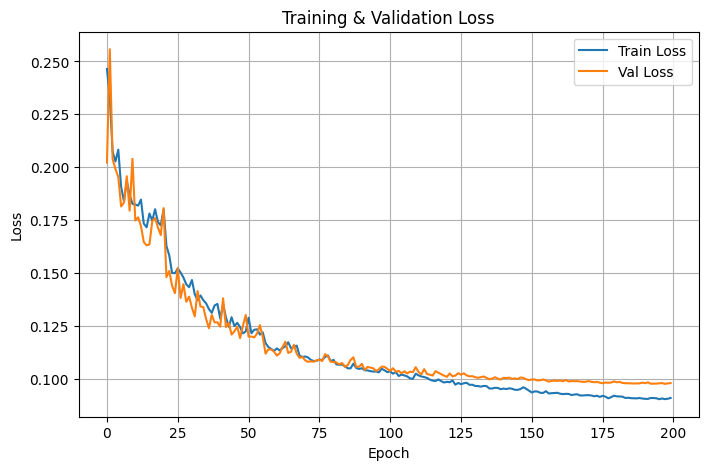

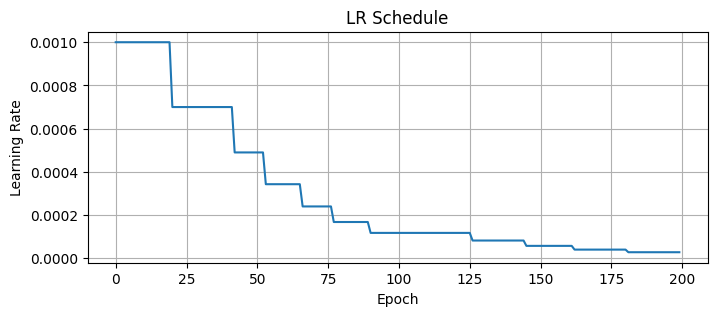

In [ ]:
# --- Train the model ---
history = train_model(
    model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=200, patience=20, plot=True
)

In [ ]:
#torch.save(model.state_dict(), 'current_model.pth')

In [ ]:
#model.load_state_dict(torch.load('current_model.pth'))

In [ ]:
f = np.logspace(np.log10(10), np.log10(10E9), 9*300)


hf = 1 / (1 + 1j*f/1000)
#hf = 1j*f/10000/(1 + 1j*f/10000)
#hf = (1 + 1j*f/100000)/(1 + 1j*f/1000)
#hf = (1j*f/(1000))/(((1j*f/10000)**2 + 1)*(1 + (1j*f/100000)**3))

mag = mag_scaler.transform([20*np.log10(np.abs(hf))])

test_X = torch.tensor(mag, dtype=torch.float32).to(device)

model.eval()
predict = model(test_X)
predict = predict.detach().cpu().numpy()
predict = y_scaler.inverse_transform(predict)
predict = 10**predict

print(predict)

[[2.8244006e+04 1.8317231e-05 5.4939097e-08 5.1390237e-01 1.5373468e-04]]


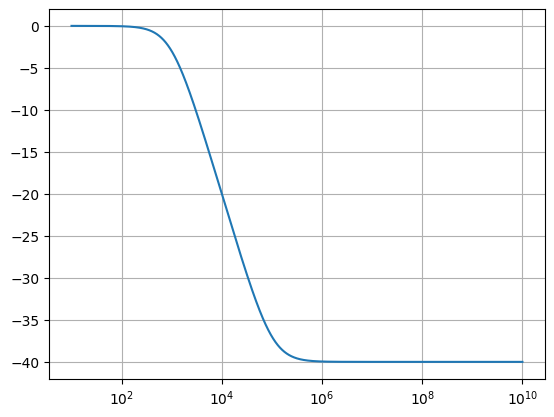

In [ ]:
plt.semilogx(f,20*np.log10(np.abs(hf)))
plt.grid()
plt.show()

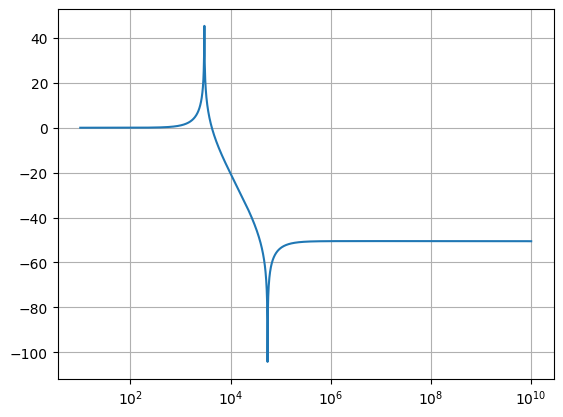

In [ ]:
R, L1, L2, C1, C2 = predict[0]
s = 1j*2*np.pi*f
yf = (C1*s)/((C1*L1*s**2 + 1)*(1/R + (C1*s)/(C1*L1*s**2 + 1) + (C2*s)/(C2*L2*s**2 + 1)))

plt.semilogx(f, 20*np.log10(np.abs(yf)))
plt.grid()
plt.show()